# Phase 5B-0.5：MPC 恢复与可行性复核

本 notebook 只读取已经落盘的 15 个代表场景、30 条闭环结果，不重新运行耗时 MPC。目标是复核：

1. 非硬安全冲突的 fallback 后斜率违约是否为 0；
2. 恢复机制是否显著提高 nominal MPC 的完整可行数；
3. oracle MPC 是否不再系统性弱于 nominal MPC；
4. 数值失败、预测域不可行、硬安全—斜率冲突是否可审计。

固定约束：电流范围 0–10 A，每个 5 s 控制步最大变化 2 A。代表门槛通过前不进入 Phase 5B-1。

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / 'configs').exists():
    ROOT = ROOT.parent
DATA = ROOT / 'data' / 'phase5b05_mpc_recovery'
METRICS_PATH = ROOT / 'outputs' / 'metrics' / 'phase5b05_metrics.json'
RUNS_PATH = DATA / 'recovery_run_summary.csv'
SUMMARY_PATH = DATA / 'recovery_controller_summary.csv'

runs = pd.read_csv(RUNS_PATH)
controller_summary = pd.read_csv(SUMMARY_PATH)
metrics = json.loads(METRICS_PATH.read_text(encoding='utf-8'))
print(f'project_root: {ROOT}')
print(f'rows: {len(runs)}, scenarios: {runs.scenario_id.nunique()}')

project_root: C:\Users\LENOVO\Documents\动力电池AI
rows: 30, scenarios: 15


## 1. 完整性与冻结结果审计

每个代表场景必须恰好包含 nominal recovery 与 oracle recovery 两条结果。

In [2]:
expected_controllers = {'nominal_mpc_recovery', 'oracle_mpc_recovery'}
controller_sets = runs.groupby('scenario_id')['controller'].agg(set)
audit = {
    'representative_scenarios': int(runs.scenario_id.nunique()),
    'completed_controller_runs': int(len(runs)),
    'all_scenarios_have_both_controllers': bool(controller_sets.eq(expected_controllers).all()),
    'duplicate_scenario_controller_pairs': int(runs.duplicated(['scenario_id', 'controller']).sum()),
    'trajectory_file_count': len(list((DATA / 'trajectories').glob('*.csv'))),
    'metrics_status': metrics['status'],
}
audit

{'representative_scenarios': 15,
 'completed_controller_runs': 30,
 'all_scenarios_have_both_controllers': True,
 'duplicate_scenario_controller_pairs': 0,
 'trajectory_file_count': 30,
 'metrics_status': 'completed'}

## 2. 控制器级结果

`operational_feasible` 同时要求目标 SOC 完成、物理安全、无硬安全—斜率冲突且普通 fallback 无斜率违约。

In [3]:
summary_columns = [
    'controller', 'scenario_count', 'baseline_feasible_count',
    'recovery_feasible_count', 'feasible_gain',
    'fallback_slew_violation_count', 'hard_safety_slew_conflict_count',
    'prediction_domain_infeasible_count', 'numerical_failure_recovered_count',
    'mean_solve_time_ms', 'maximum_solve_time_ms',
]
display(controller_summary[summary_columns].round(3))

,controller,scenario_count,baseline_feasible_count,recovery_feasible_count,feasible_gain,fallback_slew_violation_count,hard_safety_slew_conflict_count,prediction_domain_infeasible_count,numerical_failure_recovered_count,mean_solve_time_ms,maximum_solve_time_ms
0,nominal_mpc_recovery,15,5,2,-3,0,487,1220,0,837.946,5449.642
1,oracle_mpc_recovery,15,1,1,0,0,544,1427,0,867.340,5758.941


In [4]:
checks = pd.DataFrame(
    [{'check': key, 'passed': value} for key, value in metrics['checks'].items()]
)
display(checks)
print('representative_gate_passed =', metrics['representative_gate_passed'])
print('proceed_to_phase5b1 =', metrics['proceed_to_phase5b1'])

,check,passed
0,fallback_slew_violation_zero,True
1,matched_nominal_feasible_gain,False
2,oracle_not_weaker_than_nominal,False
3,failure_types_auditable,True


representative_gate_passed = False
proceed_to_phase5b1 = False


## 3. 失败类型与可行场景

普通 fallback 的斜率违约为 0，说明新的斜率安全 fallback 达到局部门槛。但主要失败已被明确归入“预测域不可行”与“硬安全—斜率冲突”，不能再笼统记为 `mpc_fallback`。

In [5]:
failure_totals = controller_summary.set_index('controller')[[
    'prediction_domain_infeasible_count',
    'hard_safety_slew_conflict_count',
    'numerical_failure_recovered_count',
    'fallback_slew_violation_count',
]].T
display(failure_totals)

feasible_runs = runs.loc[runs.operational_feasible, [
    'scenario_id', 'controller', 'selection_labels', 'charge_time_min',
    'maximum_voltage_v', 'maximum_temperature_c',
    'maximum_current_change_a', 'optimizer_success_fraction',
]].sort_values(['scenario_id', 'controller'])
display(feasible_runs.round(4))

controller,nominal_mpc_recovery,oracle_mpc_recovery
prediction_domain_infeasible_count,1220,1427
hard_safety_slew_conflict_count,487,544
numerical_failure_recovered_count,0,0
fallback_slew_violation_count,0,0


,scenario_id,controller,selection_labels,charge_time_min,maximum_voltage_v,maximum_temperature_c,maximum_current_change_a,optimizer_success_fraction
24,lhs_029,nominal_mpc_recovery,teacher_feasible,37.5833,4.1483,33.7343,2.0,1.0
28,nominal,nominal_mpc_recovery,nominal;teacher_feasible,52.3333,4.1400,33.5000,2.0,1.0
29,nominal,oracle_mpc_recovery,nominal;teacher_feasible,52.3333,4.1400,33.5000,2.0,1.0


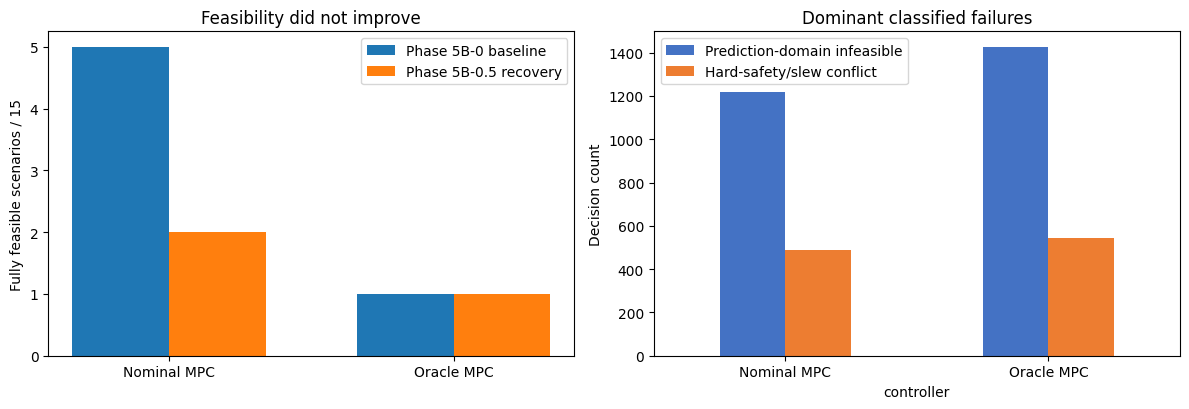

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
x = np.arange(len(controller_summary))
width = 0.34
axes[0].bar(x - width/2, controller_summary.baseline_feasible_count, width, label='Phase 5B-0 baseline')
axes[0].bar(x + width/2, controller_summary.recovery_feasible_count, width, label='Phase 5B-0.5 recovery')
axes[0].set_xticks(x, ['Nominal MPC', 'Oracle MPC'])
axes[0].set_ylabel('Fully feasible scenarios / 15')
axes[0].set_title('Feasibility did not improve')
axes[0].legend()

failure_totals.iloc[:2].T.plot.bar(ax=axes[1], color=['#4472C4', '#ED7D31'])
axes[1].set_xticklabels(['Nominal MPC', 'Oracle MPC'], rotation=0)
axes[1].set_ylabel('Decision count')
axes[1].set_title('Dominant classified failures')
axes[1].legend(['Prediction-domain infeasible', 'Hard-safety/slew conflict'])
fig.tight_layout()
plt.show()

## 4. 25 ℃ nominal 场景闭环复核

nominal 场景的两种恢复 MPC 均完整可行。下图复核电流、每步电流变化、电压与温度；虚线为对应硬约束。

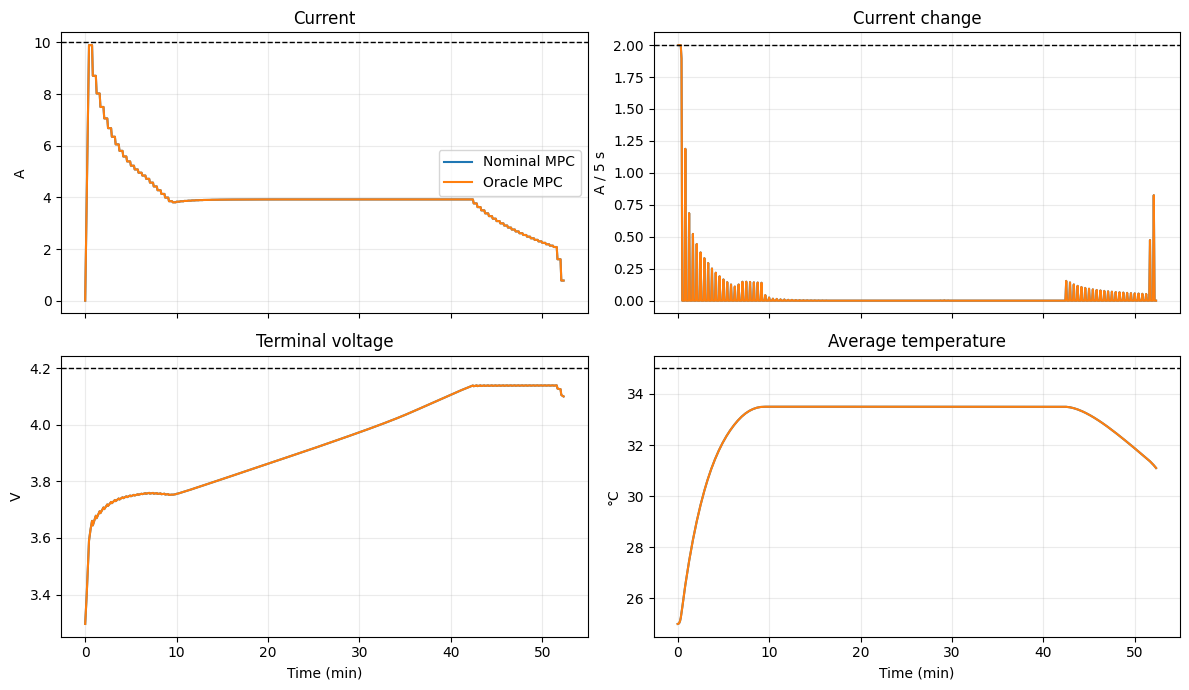

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for controller, label in [('nominal_mpc_recovery', 'Nominal MPC'), ('oracle_mpc_recovery', 'Oracle MPC')]:
    path = DATA / 'trajectories' / f'nominal__{controller}.csv'
    traj = pd.read_csv(path)
    time_min = traj.time_s / 60.0
    axes[0, 0].plot(time_min, traj.charge_current_a, label=label)
    axes[0, 1].plot(time_min.iloc[1:], traj.current_change_a.iloc[1:], label=label)
    axes[1, 0].plot(time_min, traj.terminal_voltage_v, label=label)
    axes[1, 1].plot(time_min, traj.true_average_temperature_c, label=label)
axes[0, 0].axhline(10.0, color='black', linestyle='--', linewidth=1)
axes[0, 1].axhline(2.0, color='black', linestyle='--', linewidth=1)
axes[1, 0].axhline(4.2, color='black', linestyle='--', linewidth=1)
axes[1, 1].axhline(35.0, color='black', linestyle='--', linewidth=1)
for ax, title, ylabel in zip(axes.flat, ['Current', 'Current change', 'Terminal voltage', 'Average temperature'], ['A', 'A / 5 s', 'V', '°C']):
    ax.set_title(title); ax.set_ylabel(ylabel); ax.grid(alpha=0.25)
for ax in axes[1]: ax.set_xlabel('Time (min)')
axes[0, 0].legend()
fig.tight_layout()
plt.show()

In [8]:
nominal_rows = runs[runs.scenario_id.eq('nominal')][[
    'controller', 'completion_success', 'physical_safe', 'operational_feasible',
    'charge_time_min', 'maximum_voltage_v', 'maximum_temperature_c',
    'maximum_current_change_a', 'prediction_domain_infeasible_count',
    'hard_safety_slew_conflict_count',
]]
display(nominal_rows.round(5))

,controller,completion_success,physical_safe,operational_feasible,charge_time_min,maximum_voltage_v,maximum_temperature_c,maximum_current_change_a,prediction_domain_infeasible_count,hard_safety_slew_conflict_count
28,nominal_mpc_recovery,True,True,True,52.33333,4.14,33.5,2.0,0,0
29,oracle_mpc_recovery,True,True,True,52.33333,4.14,33.5,2.0,0,0


## 5. 结论与下一步

- **局部成功**：普通 fallback 后斜率违约为 0；失败已能区分为预测域不可行和硬安全—斜率冲突；25 ℃ nominal 闭环两种 MPC 均完整可行。
- **代表集失败**：nominal recovery 仅 2/15 完整可行，相对所选场景的 Phase 5B-0 基线 5/15 反而减少 3；oracle recovery 为 1/15，且弱于 nominal recovery。
- **失败主因**：累计出现 2647 次预测域不可行和 1031 次硬安全—斜率冲突；不是普通 fallback 引入的斜率越界。
- **决策**：代表门槛未通过，不运行完整 69 场景恢复复核，不进入 Phase 5B-1。下一步应先检查预测域候选审计为何比 Phase 5B-0 的完整可行定义更严格，并审计 4.2 V/35 ℃ 硬安全阈值与控制预测阈值的一致性。